In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score


df_clean = pd.read_csv("../data/processed/df_clean.csv")

cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"
]

### Rebuilding df_prepare_clustring

In [10]:
df_prepare_clustering = df_clean.copy()
for col in cols:
    df_prepare_clustering[col] = np.log1p(df_prepare_clustering[col])

scaler = StandardScaler()
df_prepare_clustering[cols] = scaler.fit_transform(df_prepare_clustering[cols])

# FS3

## KMeans

### Grid Search (search for the best combinision between k & n_components)

In [11]:
# K-means grid search
kmeans_results = []

for n_comp in range(2, 6):
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(df_prepare_clustering[cols])

    for k in range(2, 8):
        model = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels = model.fit_predict(X_pca)

        if len(np.unique(labels)) < 2:
            continue

        sil = silhouette_score(X_pca, labels)
        inertia = model.inertia_

        kmeans_results.append({
            "n_components": n_comp,
            "k": k,
            "silhouette": sil,
            "inertia": inertia,
        })

kmeans_df = pd.DataFrame(kmeans_results)
kmeans_df = kmeans_df.sort_values("silhouette", ascending=False).reset_index(drop=True)

print("Best K-means combinations by silhouette:")
print(kmeans_df.head(10).to_string(index=False))


Best K-means combinations by silhouette:
 n_components  k  silhouette      inertia
            2  3    0.448740 13244.219895
            2  2    0.430953 23542.395938
            2  4    0.422441 10414.330261
            2  5    0.410143  8242.893472
            3  6    0.398559 11704.690227
            2  7    0.397941  5634.987347
            2  6    0.394468  6685.677412
            3  5    0.390936 13780.497331
            3  4    0.388879 16447.663546
            3  3    0.382649 20205.727848


In [12]:
# Best K-means model
best_kmeans = kmeans_df.iloc[0]
best_n_components = int(best_kmeans["n_components"])
best_k = int(best_kmeans["k"])

pca_best = PCA(n_components=best_n_components)
X_pca_best = pca_best.fit_transform(df_prepare_clustering[cols])

kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels_best = kmeans_best.fit_predict(X_pca_best)

df_clean["cluster_kmeans"] = labels_best

print(f"Selected PCA components: {best_n_components}")
print(f"Selected K: {best_k}")
print(df_clean["cluster_kmeans"].value_counts().sort_index())


Selected PCA components: 2
Selected K: 3
cluster_kmeans
0    2428
1    3393
2    3128
Name: count, dtype: int64


### Elbow curve and silhouette curve

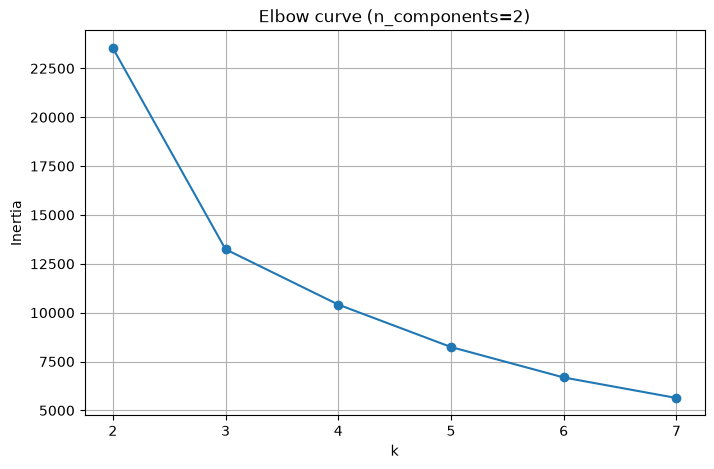

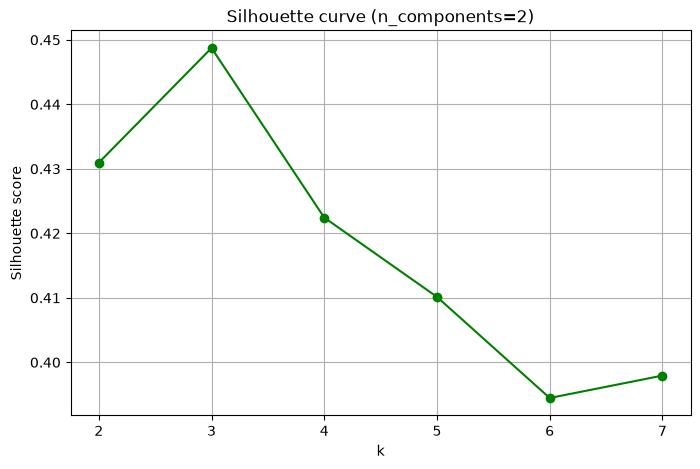

In [13]:
subset = kmeans_df[kmeans_df["n_components"] == best_n_components].sort_values("k")

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(subset["k"], subset["inertia"], marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow curve (n_components=2)")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(subset["k"], subset["silhouette"], marker="o", color="green")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.title("Silhouette curve (n_components=2)")
plt.grid(True)
plt.show()

In [14]:
pca_final = PCA(n_components=2)
X_pca_final = pca_final.fit_transform(df_prepare_clustering[cols])

kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=20)
labels_final = kmeans_final.fit_predict(X_pca_final)

pd.Series(labels_best).value_counts(normalize=True) * 100

1    37.914851
2    34.953626
0    27.131523
Name: proportion, dtype: float64

In [15]:
df_clean.to_csv("../data/processed/df_clean.csv", index=False)

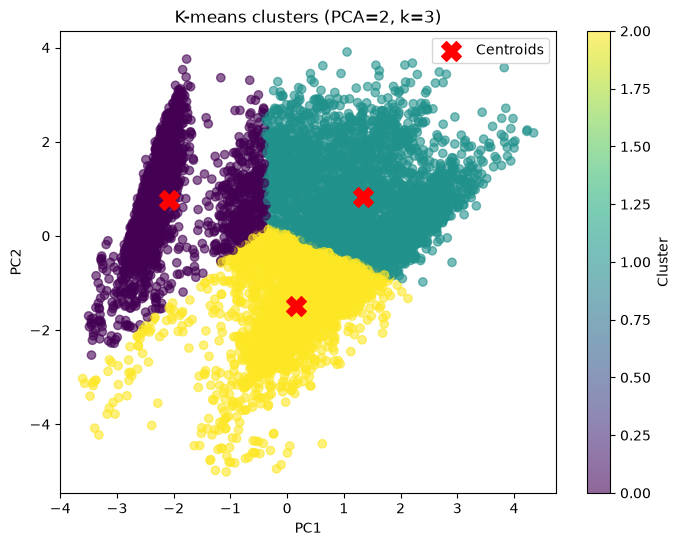

In [16]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca_best[:, 0], X_pca_best[:, 1], c=labels_best, cmap="viridis", alpha=0.6)

centers = kmeans_best.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c="red", marker="X", s=200, label="Centroids")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-means clusters (PCA={best_n_components}, k={best_k})")
plt.legend()
plt.colorbar(scatter, label="Cluster")
plt.show()

## DBSCANE

### DBSCAN grid search
Compare several combinations of PCA dimensions, eps and min_samples, then keep the best valid model.


In [17]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan_results = []

eps_values = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]
min_samples_values = [5, 10, 15, 20]

for n_comp in range(2, 6):
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(df_prepare_clustering[cols])

    for eps in eps_values:
        for min_samples in min_samples_values:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(X_pca)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_ratio = (labels == -1).sum() / len(labels)

            # need at least 2 real clusters to compute silhouette
            if n_clusters < 2:
                continue

            # silhouette requires excluding noise points (-1)
            mask = labels != -1
            sil = silhouette_score(X_pca[mask], labels[mask])

            dbscan_results.append({
                "n_components": n_comp,
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_ratio": noise_ratio,
                "silhouette": sil,
            })

dbscan_df = pd.DataFrame(dbscan_results)
dbscan_df = dbscan_df.sort_values("silhouette", ascending=False).reset_index(drop=True)

print("Best DBSCAN combinations by silhouette:")
print(dbscan_df.head(10).to_string(index=False))

Best DBSCAN combinations by silhouette:
 n_components  eps  min_samples  n_clusters  noise_ratio  silhouette
            4  0.3           20           7     0.620516    0.512059
            5  0.3           20           7     0.737066    0.506597
            2  0.3           15           2     0.018661    0.452707
            3  0.3           20           5     0.158900    0.431111
            2  0.3            5           2     0.003017    0.421375
            5  0.3           15           9     0.697285    0.411167
            3  0.3           15           5     0.114203    0.407209
            2  0.3           20           3     0.026372    0.406861
            2  0.3           10           3     0.010280    0.388007
            5  1.5           15           2     0.001788    0.381534


### cluster_dbscane & est_atypique_dbscane

In [20]:
best_dbscan = dbscan_df[dbscan_df["noise_ratio"] < 0.05].iloc[0]

pca_dbscan = PCA(n_components=int(best_dbscan["n_components"]))
X_pca_dbscan = pca_dbscan.fit_transform(df_prepare_clustering[cols])

dbscan_final = DBSCAN(eps=best_dbscan["eps"], min_samples=int(best_dbscan["min_samples"]))
labels_dbscan = dbscan_final.fit_predict(X_pca_dbscan)

df_clean["cluster_dbscan"] = labels_dbscan
df_clean["est_atypique_dbscan"] = (labels_dbscan == -1)

df_clean["cluster_dbscan"].value_counts()

cluster_dbscan
 0    6759
 1    2023
-1     167
Name: count, dtype: int64

### KMeans vs dbscane

In [21]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

comparison = pd.DataFrame([
    {
        "method": "KMeans",
        "silhouette": silhouette_score(X_pca_best, labels_best),
        "davies_bouldin": davies_bouldin_score(X_pca_best, labels_best),
        "calinski_harabasz": calinski_harabasz_score(X_pca_best, labels_best),
        "noise_pct": 0.0,
    },
    {
        "method": "DBSCAN",
        "silhouette": best_dbscan["silhouette"],
        "davies_bouldin": davies_bouldin_score(X_pca_dbscan[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1]),
        "calinski_harabasz": calinski_harabasz_score(X_pca_dbscan[labels_dbscan != -1], labels_dbscan[labels_dbscan != -1]),
        "noise_pct": best_dbscan["noise_ratio"] * 100,
    },
])
comparison

,method,silhouette,davies_bouldin,calinski_harabasz,noise_pct
0,KMeans,0.448740,0.773718,9198.594795,0.00000
1,DBSCAN,0.452707,0.762101,6324.639274,1.86613


### KMeans wins

In [26]:
df_clean["cluster_final"] = df_clean["cluster_kmeans"]
df_clean.to_csv("../data/processed/df_clean.csv", index=False)

# FS4

### Cluster mean std

In [23]:
df_prepare_clustering["cluster_kmeans"] = labels_best

cluster_mean_std = (
    df_prepare_clustering.groupby("cluster_kmeans")[cols]
    .mean()
    .sort_index()
    .round(3)
)

print("Moyennes par cluster (vue standardisée)")
display(cluster_mean_std)

Moyennes par cluster (vue standardisée)


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster_kmeans,,,,,,,
0,0.496,-1.402,-0.798,-1.023,1.003,-0.122,-0.006
1,0.454,0.780,0.872,0.477,-0.025,0.602,0.569
2,-0.878,0.242,-0.327,0.276,-0.752,-0.559,-0.612


### cluster mean real

In [24]:
cluster_mean_real = (
    df_clean.groupby("cluster_kmeans")[cols]
    .mean()
    .sort_index()
    .round(2)
)

print("Moyennes par cluster (vue réelle)")
display(cluster_mean_real)

Moyennes par cluster (vue réelle)


,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS
cluster_kmeans,,,,,,,
0,2176.51,23.80,19.04,4.81,2008.69,3982.50,1630.55
1,2263.95,2198.83,1411.38,787.69,1095.70,6525.86,2888.63
2,331.16,466.83,149.39,318.01,53.03,2688.33,559.95


### Verifying the target

In [27]:
cluster_names = {
    0: "Clients à Risque",
    1: "Clients Premium",
    2: "Clients à Faible Activité"
}

df_clean["target"] = df_clean["cluster_final"].map(cluster_names)

# sanity checks
print(df_clean["target"].isnull().sum())  # should be 0
print(df_clean["target"].value_counts())
print(df_clean["cluster_final"].value_counts().sort_index())

0
target
Clients Premium              3393
Clients à Faible Activité    3128
Clients à Risque             2428
Name: count, dtype: int64
cluster_final
0    2428
1    3393
2    3128
Name: count, dtype: int64


### save

In [28]:
df_clean.to_csv("../data/processed/df_clean.csv", index=False)

### Heatmap of standardized cluster means

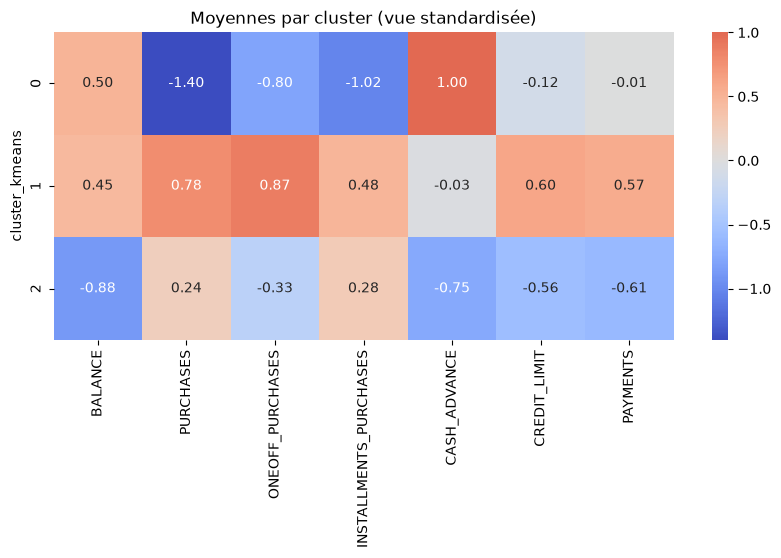

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.heatmap(cluster_mean_std, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Moyennes par cluster (vue standardisée)")
plt.show()

### Cluster size bar chart

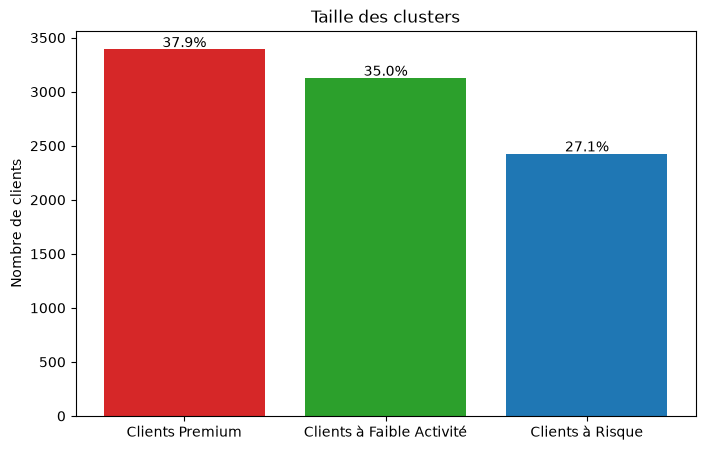

In [30]:
sizes = df_clean["target"].value_counts()
sizes_pct = df_clean["target"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(sizes.index, sizes.values, color=["#d62728", "#2ca02c", "#1f77b4"])
plt.ylabel("Nombre de clients")
plt.title("Taille des clusters")

for bar, pct in zip(bars, sizes_pct.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
              f"{pct:.1f}%", ha="center")

plt.show()

### Small bar charts comparing key variables across clusters (real values):

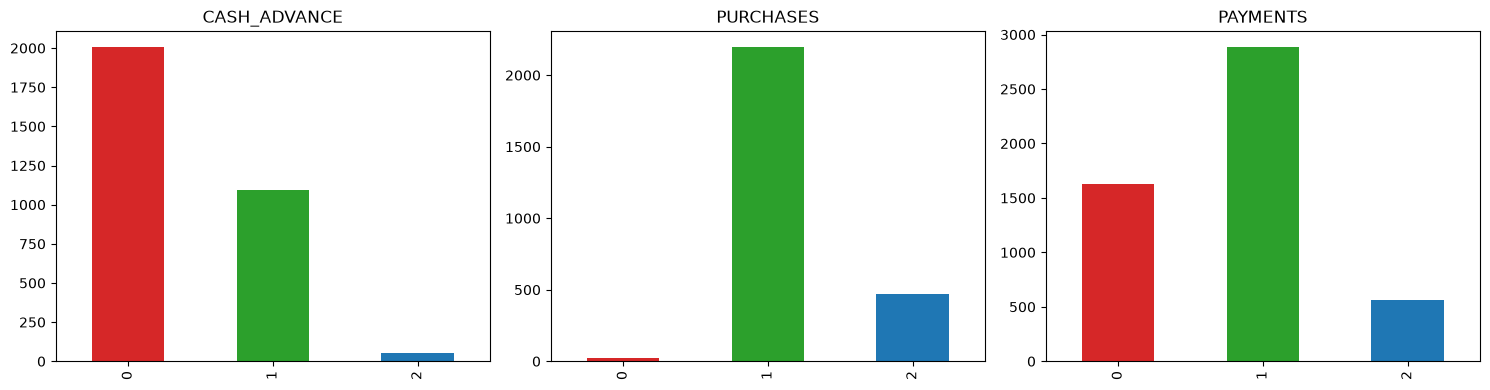

In [31]:
key_vars = ["CASH_ADVANCE", "PURCHASES", "PAYMENTS"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, var in zip(axes, key_vars):
    cluster_mean_real[var].plot(kind="bar", ax=ax, color=["#d62728", "#2ca02c", "#1f77b4"])
    ax.set_title(var)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()